## EDA

In [1]:
import pandas as pd
crimes_data = pd.read_csv('Competition_Dataset.csv')

In [13]:
crimes_data

,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,Latitude (Y),Longitude (X),Year,Month,Hour
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,2015,5,23
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,2015,5,23
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414,2015,5,23
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873,2015,5,23
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541,2015,5,23
...,...,...,...,...,...,...,...,...,...,...,...,...
680821,2003-01-06 00:15:00,ROBBERY,ROBBERY ON THE STREET WITH A GUN,Monday,TARAVAL,NONE,FARALLONES ST / CAPITOL AV,-122.459033,37.714056,2003,1,0
680822,2003-01-06 00:01:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Monday,INGLESIDE,NONE,600 Block of EDNA ST,-122.447364,37.731948,2003,1,0
680823,2003-01-06 00:01:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Monday,SOUTHERN,NONE,5TH ST / FOLSOM ST,-122.403390,37.780266,2003,1,0
680824,2003-01-06 00:01:00,VANDALISM,"MALICIOUS MISCHIEF, VANDALISM OF VEHICLES",Monday,SOUTHERN,NONE,TOWNSEND ST / 2ND ST,-122.390531,37.780607,2003,1,0


In [3]:
crimes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 680826 entries, 0 to 680825
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Dates          680826 non-null  object 
 1   Category       680826 non-null  object 
 2   Descript       680826 non-null  object 
 3   DayOfWeek      680826 non-null  object 
 4   PdDistrict     680826 non-null  object 
 5   Resolution     680826 non-null  object 
 6   Address        680826 non-null  object 
 7   Latitude (Y)   680826 non-null  float64
 8   Longitude (X)  680826 non-null  float64
dtypes: float64(2), object(7)
memory usage: 46.7+ MB


In [17]:
print(crimes_data.isnull().sum())
print(crimes_data.duplicated().sum())

Dates            0
Category         0
Descript         0
DayOfWeek        0
PdDistrict       0
Resolution       0
Address          0
Latitude (Y)     0
Longitude (X)    0
Year             0
Month            0
Hour             0
dtype: int64
11084


In [18]:
#there is 11084 duplacated rows in the dataset
crimes_data.drop_duplicates(inplace=True)
crimes_data.duplicated().sum()

0

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#convert the Dates column to datetime format
#extract the year, month, and hour from the Dates column
crimes_data['Dates'] = pd.to_datetime(crimes_data['Dates'])
crimes_data['Year'] = crimes_data['Dates'].dt.year
crimes_data['Month'] = crimes_data['Dates'].dt.month
crimes_data['Hour'] = crimes_data['Dates'].dt.hour

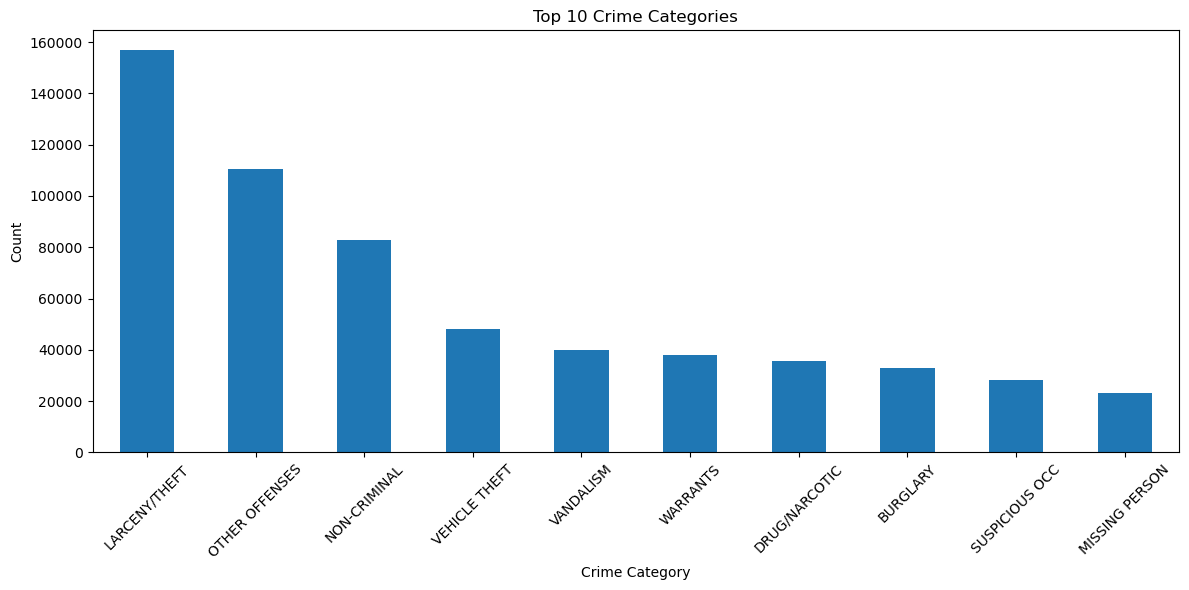

In [21]:
crime_counts = crimes_data['Category'].value_counts()
plt.figure(figsize=(12, 6))
crime_counts[:10].plot(kind='bar')
plt.title('Top 10 Crime Categories')
plt.ylabel('Count')
plt.xlabel('Crime Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

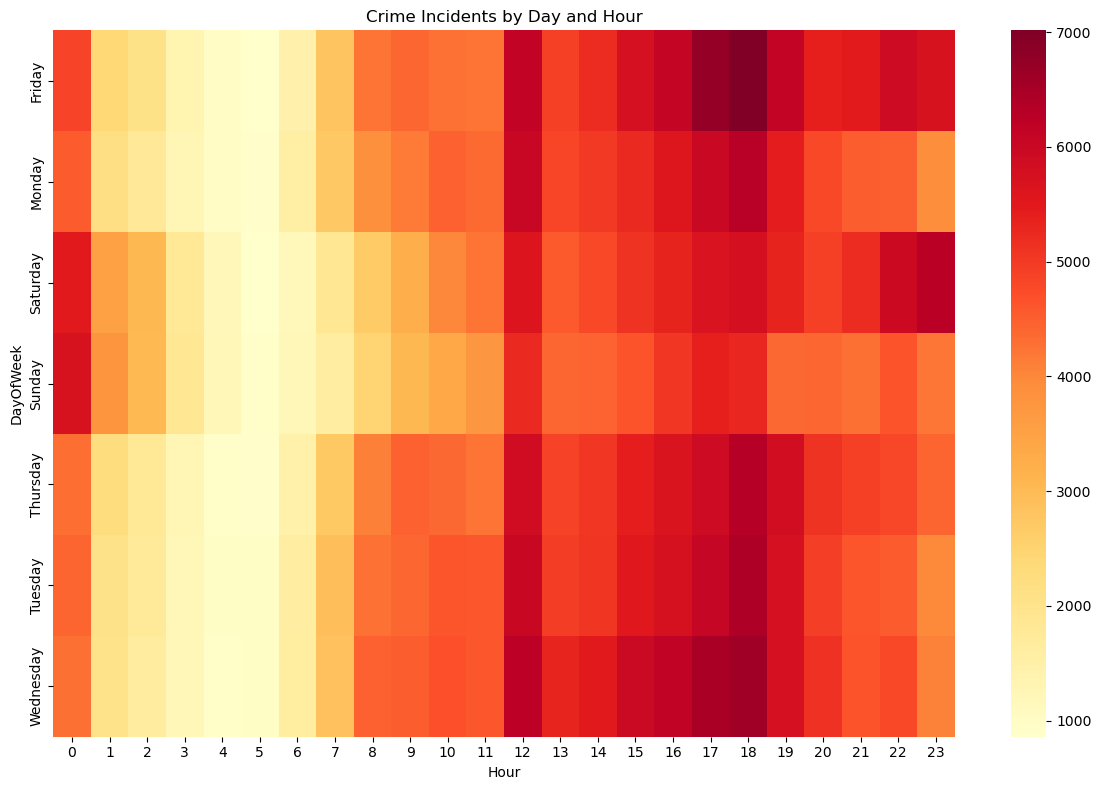

In [8]:
day_hour = pd.crosstab(crimes_data['DayOfWeek'], crimes_data['Hour'])
plt.figure(figsize=(12, 8))
sns.heatmap(day_hour, cmap="YlOrRd")
plt.title('Crime Incidents by Day and Hour')
plt.tight_layout()
plt.show()

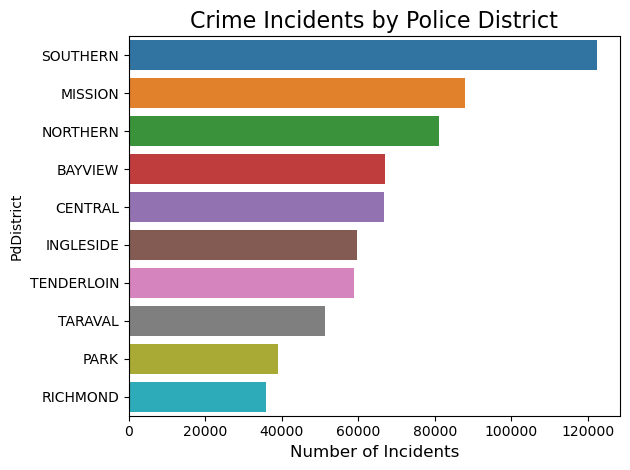

In [22]:
district_counts = crimes_data['PdDistrict'].value_counts()
sns.barplot(x=district_counts.values, y=district_counts.index)
plt.title('Crime Incidents by Police District', fontsize=16)
plt.xlabel('Number of Incidents', fontsize=12)
plt.tight_layout()

d:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


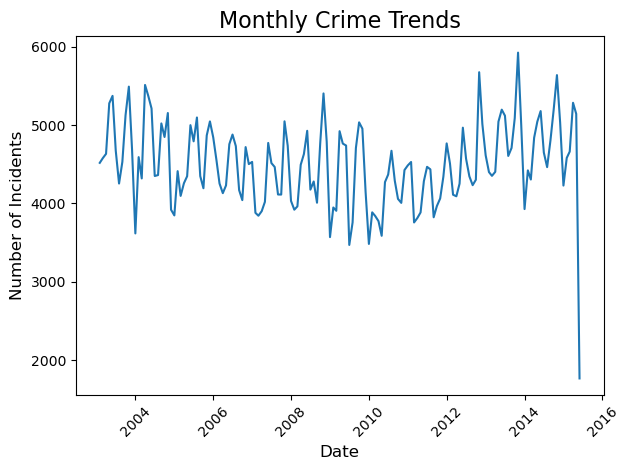

In [23]:
monthly_crimes = crimes_data.groupby(pd.Grouper(key='Dates', freq='M')).size()
sns.lineplot(x=monthly_crimes.index, y=monthly_crimes.values)
plt.title('Monthly Crime Trends', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

In [43]:
crimes_data['Descript'].unique()

array(['WARRANT ARREST', 'TRAFFIC VIOLATION ARREST',
       'GRAND THEFT FROM LOCKED AUTO', 'GRAND THEFT FROM UNLOCKED AUTO',
       'STOLEN AUTOMOBILE', 'PETTY THEFT FROM LOCKED AUTO',
       'MISCELLANEOUS INVESTIGATION',
       'MALICIOUS MISCHIEF, VANDALISM OF VEHICLES', 'FOUND PROPERTY',
       'ROBBERY, ARMED WITH A KNIFE', 'TRAFFIC VIOLATION',
       'ROBBERY, BODILY FORCE',
       'STAY AWAY OR COURT ORDER, NON-DV RELATED',
       'ATTEMPTED THEFT FROM LOCKED VEHICLE', 'CIVIL SIDEWALKS, CITATION',
       'MALICIOUS MISCHIEF, VANDALISM', 'SUSPICIOUS PACKAGE',
       'AIDED CASE, MENTAL DISTURBED', 'PETTY THEFT SHOPLIFTING',
       'PROBATION VIOLATION', 'DRIVERS LICENSE, SUSPENDED OR REVOKED',
       'STOLEN MOTORCYCLE', 'GRAND THEFT FROM PERSON',
       'BURGLARY, VEHICLE (ARREST MADE)',
       'ATTEMPTED ROBBERY ON THE STREET WITH BODILY FORCE',
       'PETTY THEFT FROM A BUILDING', 'STOLEN AND RECOVERED VEHICLE',
       'INVESTIGATIVE DETENTION', 'ENROUTE TO OUTSIDE JURISDICT

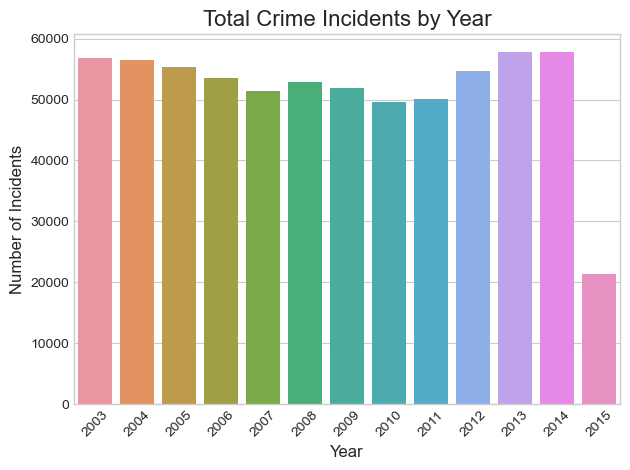

In [26]:

# 1. Total Crime by Year
yearly_crime = crimes_data['Year'].value_counts().sort_index()
sns.barplot(x=yearly_crime.index, y=yearly_crime.values)
plt.title('Total Crime Incidents by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Key Insights So Far:
- The dataset contains 669,742 unique crime records.
- Crimes are categorized into different types, with some being more frequent than others.
- Police district and geographic coordinates allow for spatial crime analysis.
- Time-related features can help identify patterns such as peak crime periods.

# Crime Classification & Severity Assignment

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [49]:
X = crimes_data['Descript']  # Crime descriptions (text)
y = crimes_data['Category']  # Crime categories (labels)

# Convert text data to numerical format using TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000,ngram_range=(1,2),min_df=5,max_df=0.9,lowercase=True)  # Remove common words & limit features
X_tfidf = vectorizer.fit_transform(X)

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [50]:
# Train a Naive Bayes classifier (good for text classification)
model = MultinomialNB()
model.fit(X_train, y_train)

# Predict crime categories on the test set
y_pred = model.predict(X_test)

In [51]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 1.00
Classification Report:
                         precision    recall  f1-score   support

                 ARSON       0.99      1.00      1.00       285
            BAD CHECKS       1.00      1.00      1.00        65
               BRIBERY       1.00      1.00      1.00        45
              BURGLARY       1.00      1.00      1.00      6583
    DISORDERLY CONDUCT       1.00      1.00      1.00       787
         DRUG/NARCOTIC       1.00      1.00      1.00      6983
          EMBEZZLEMENT       1.00      1.00      1.00       239
             EXTORTION       1.00      1.00      1.00        40
FORGERY/COUNTERFEITING       1.00      1.00      1.00      1731
                 FRAUD       1.00      1.00      1.00      3022
            KIDNAPPING       1.00      1.00      1.00       455
         LARCENY/THEFT       1.00      1.00      1.00     31347
        MISSING PERSON       1.00      1.00      1.00      4629
          NON-CRIMINAL       1.00      1.00      1.00     

In [52]:
from sklearn.linear_model import LogisticRegression
log_reg_model = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial', random_state=42)
log_reg_model.fit(X_train, y_train)

# Predict on the test set
y_pred_logreg = log_reg_model.predict(X_test)

In [53]:
# Model accuracy
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Accuracy: {accuracy_logreg:.2f}")

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred_logreg))

Logistic Regression Accuracy: 1.00
Classification Report:
                         precision    recall  f1-score   support

                 ARSON       1.00      1.00      1.00       285
            BAD CHECKS       1.00      1.00      1.00        65
               BRIBERY       1.00      1.00      1.00        45
              BURGLARY       1.00      1.00      1.00      6583
    DISORDERLY CONDUCT       1.00      1.00      1.00       787
         DRUG/NARCOTIC       1.00      1.00      1.00      6983
          EMBEZZLEMENT       1.00      1.00      1.00       239
             EXTORTION       1.00      1.00      1.00        40
FORGERY/COUNTERFEITING       1.00      1.00      1.00      1731
                 FRAUD       1.00      1.00      1.00      3022
            KIDNAPPING       1.00      1.00      1.00       455
         LARCENY/THEFT       1.00      1.00      1.00     31347
        MISSING PERSON       1.00      1.00      1.00      4629
          NON-CRIMINAL       1.00      1.00 

In [36]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 1.00
Classification Report:
                         precision    recall  f1-score   support

                 ARSON       1.00      1.00      1.00       285
            BAD CHECKS       1.00      1.00      1.00        65
               BRIBERY       0.92      1.00      0.96        45
              BURGLARY       1.00      1.00      1.00      6583
    DISORDERLY CONDUCT       1.00      1.00      1.00       787
         DRUG/NARCOTIC       1.00      1.00      1.00      6983
          EMBEZZLEMENT       0.99      1.00      0.99       239
             EXTORTION       1.00      1.00      1.00        40
FORGERY/COUNTERFEITING       1.00      1.00      1.00      1731
                 FRAUD       1.00      1.00      1.00      3022
            KIDNAPPING       1.00      1.00      1.00       455
         LARCENY/THEFT       1.00      1.00      1.00     31347
        MISSING PERSON       1.00      1.00      1.00      4629
          NON-CRIMINAL       1.00      1.00      1.00     

In [37]:
# Create a mapping of crime categories to severity levels
severity_mapping = {
    "NON-CRIMINAL": 1, "SUSPICIOUS OCCURRENCE": 1, "MISSING PERSON": 1, "RUNAWAY": 1, "RECOVERED VEHICLE": 1,
    "WARRANTS": 2, "OTHER OFFENSES": 2, "VANDALISM": 2, "TRESPASS": 2, "DISORDERLY CONDUCT": 2, "BAD CHECKS": 2,
    "LARCENY/THEFT": 3, "VEHICLE THEFT": 3, "FORGERY/COUNTERFEITING": 3, "DRUG/NARCOTIC": 3, "STOLEN PROPERTY": 3,
    "FRAUD": 3, "BRIBERY": 3, "EMBEZZLEMENT": 3,
    "ROBBERY": 4, "WEAPON LAWS": 4, "BURGLARY": 4, "EXTORTION": 4,
    "KIDNAPPING": 5, "ARSON": 5
}

# Function to assign severity based on predicted category
def assign_severity(category):
    return severity_mapping.get(category, 0)  # Default to 0 if not found

# Apply severity mapping
crimes_data['Severity'] = crimes_data['Category'].map(assign_severity)
